<a href="https://colab.research.google.com/github/MariiaOmelianenko/Exploratory-data-analysis-for-online-store/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



##Data overview



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Matplotlib_Seaborn

# Uploading dataset
products = pd.read_csv("products.csv")
products.head()


Mounted at /content/drive
/content/drive/MyDrive/Matplotlib_Seaborn


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
countries = pd.read_csv("countries.csv")
countries.head()


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
events = pd.read_csv("events.csv")
events.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# Information about datasets
print(products.shape)
products.info()

print(countries.shape)
countries.info()

print(events.shape)
events.info()

(12, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
(249, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
(1330, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   i

Маємо датасет який складається 3х таблиць: products (містить id продукту та його назву), countries (назва краіни, регіону, субрегіону та код краіни з 2х та 3х літер), events (id замовлення, дати замовлення та відправки, приорітет замовлення, код країни з 3х літер, id продукта, канал продажу, продані одиниці, ціна та собівартість одиниці товару).

Маємо поодинокі пропуски в таблицях сountries та events, невірний тип даних в колонках Order Date та Ship Date.


##Data cleaning

In [ ]:
# Percentage of null
print(countries.isna().sum() / countries.shape[0] * 100)
print(events.isna().sum() / events.shape[0] * 100)


name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


Враховуючи наявність пропусків в таблиці countries, їх відсоток (<0,4%) найоптимальнішим рішенням буде видалення рядків, що містять пропущені дані. В таблиці events також наявні пропущені значення. Так як в стовпці Units Sold маємо 0,15% пропусків, іх також можна видалити, але у випадку з Country Code, де частка пропущених значень складає 6.17%, вважаю за оптимальне спочатку перевірити чи не є це якоюсь системною помилкою в заповненні даних, чи немає закономірностей в Order ID або	Order Date.  

In [ ]:
# Inspect rows with missing Country Code
events[events["Country Code"].isna()].head(10)

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
48,128766906,2/13/2011,3/28/2011,C,NaN,7940,Offline,3844.0,668.27,502.54
50,129169023,6/8/2012,7/18/2012,M,NaN,1270,Offline,2839.0,47.45,31.79
58,133276450,1/27/2016,3/15/2016,H,NaN,3127,Online,8318.0,81.73,56.67
66,139949357,7/1/2014,7/14/2014,H,NaN,5988,Online,2980.0,154.06,90.93
83,150293242,5/19/2015,6/21/2015,H,NaN,8681,Offline,3965.0,651.21,524.96


Судячи з усього помилка не є системною, тобто маємо справу з випадковими пропусками. Але враховуючи доволі високий відсоток пропусків, спробую залишити дані без видалення, а таблиці обʼєднувати через Left Join, задля уникнення втрати великої кількості даних.

In [ ]:
# Dropping null
countries = countries.dropna()
events = events.dropna(subset=["Units Sold"])

In [ ]:
# Convert the date columns to datetime
events["Order Date"] = pd.to_datetime(events["Order Date"], format="%m/%d/%Y")

events["Ship Date"] = pd.to_datetime(events["Ship Date"], format="%m/%d/%Y")

events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


In [ ]:
# Checking for duplicates in data
duplicate_rows_e = events.duplicated()
print(duplicate_rows_e.sum())

duplicate_rows_c = countries.duplicated()
print(duplicate_rows_c.sum())

0
0


In [ ]:
#Anomalies in events Table
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
#Difference betveen Ship Date and Order Date
(events["Ship Date"] - events["Order Date"]).describe()

,0
count,1328
mean,24 days 18:53:07.951807229
std,14 days 14:03:53.947673625
min,0 days 00:00:00
25%,12 days 00:00:00
50%,25 days 00:00:00
75%,37 days 00:00:00
max,50 days 00:00:00


В таблиці events немає від’ємних значень, немає нулів, дати в логічному діапазоні, відсутні очевидні екстремальні значення.

In [ ]:
#Anomalies in countries Table
print(countries.describe())
countries["region"].value_counts()

               name alpha-2 alpha-3  region                       sub-region
count           247     247     247     247                              247
unique          247     247     247       5                               17
top     Afghanistan      AF     AFG  Africa  Latin America and the Caribbean
freq              1       1       1      59                               52


,count
region,
Africa,59
Americas,57
Asia,51
Europe,51
Oceania,29


Countries також не містить аномалій в даних.

In [ ]:
#Data Joining
df = events.merge(products, left_on="Product ID", right_on="id", how="left")
df = df.merge(countries, left_on="Country Code", right_on="alpha-3", how="left")

df = df.drop(["alpha-2", "id"], axis=1)

df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False).str.replace("-", "_", regex=False))
df = df.rename(columns={"name": "country", "item_type": "category"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1246 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
 10  category        1328 non-null   object        
 11  country         1246 non-null   object        
 12  alpha_3         1246 non-null   object        
 13  region          1246 non-null   object        
 14  sub_region      1246 non-null   object        
dtypes: d

##Data analysis and visualization

###Total metrics Analysis

In [ ]:
#Total metrics
total_orders = df["order_id"].nunique()

df["profit_per_unit"] = df["unit_price"] - df["unit_cost"]
total_profit = (df["profit_per_unit"] * df["units_sold"]).sum()

total_countries = df["country"].nunique()

total_regions = df["region"].nunique()


print("Total Orders:", total_orders)
print("Total Profit:", total_profit)
print("Total Countries:", total_countries)
print("Total Regions:", total_regions)

Total Orders: 1328
Total Profit: 501434459.0
Total Countries: 45
Total Regions: 2


Загальна кількість замовлень - 1328

Загальний прибукток - 501434459.0

Охоплених країн - 45

Регіонів - 2

Маємо певну розбіжність по регіонах, до обʼєднання таблиць регіонів в таблиці countries було 5, але після обʼєднання бачимо 2 регіони, це свідчить по те, що замовлення відправлялись тільки в 2 регіони з 5 існуючих.

In [ ]:
# Grouping by category and channel
grouped_by_category = df.groupby("category")["units_sold"].sum()

grouped_by_channel = df.groupby("sales_channel")["units_sold"].sum()

print("Total units sold for each category:", grouped_by_category)
print("Total units sold by different channels:", grouped_by_channel)

Total units sold for each category: category
Baby Food          562706.0
Beverages          613133.0
Cereal             465685.0
Clothes            591385.0
Cosmetics          533291.0
Fruits             591672.0
Household          440249.0
Meat               530380.0
Office Supplies    617641.0
Personal Care      557678.0
Snacks             490160.0
Vegetables         582544.0
Name: units_sold, dtype: float64
Total units sold by different channels: sales_channel
Offline    3320363.0
Online     3243236.0
online       12925.0
Name: units_sold, dtype: float64


In [ ]:
# Lowercase of sales channel
df["sales_channel"] = df["sales_channel"].str.lower()
df["sales_channel"].nunique()

2

###Sales Analysis by Category

Text(0, 0.5, 'Popularity')

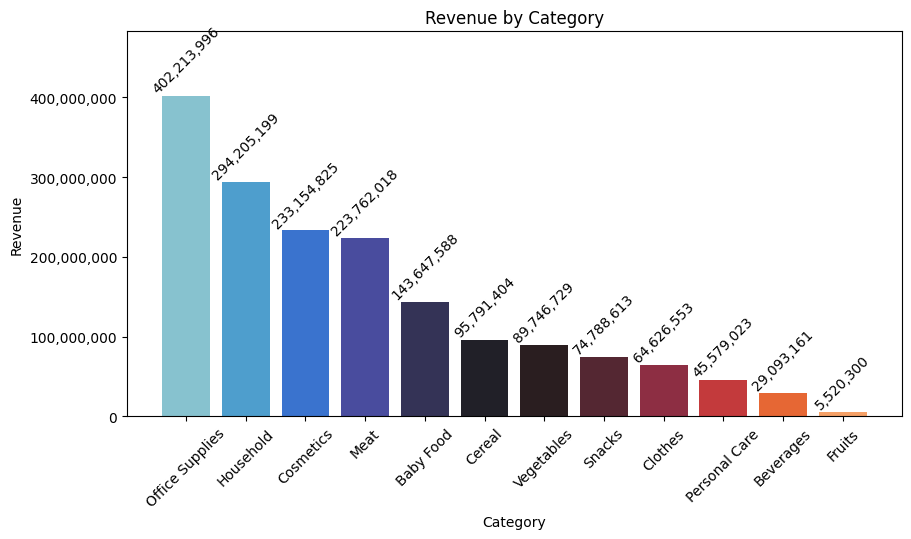

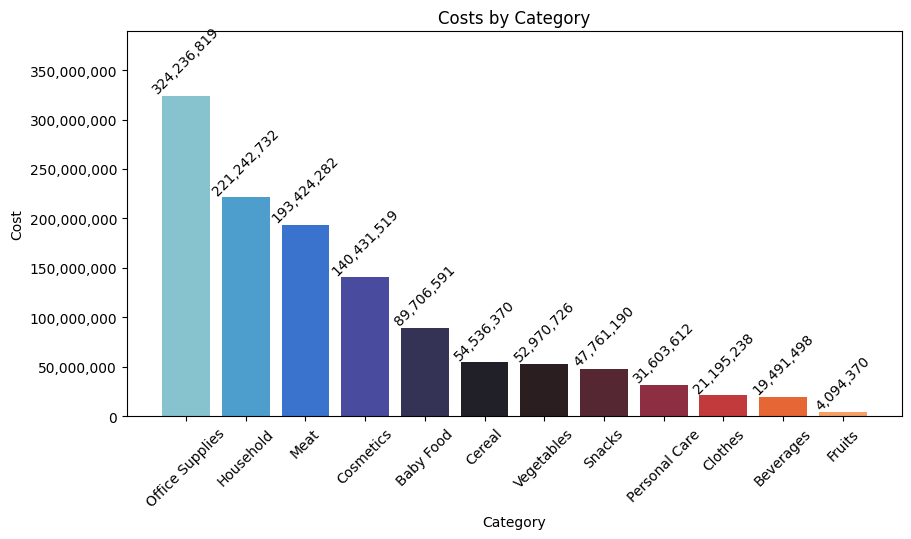

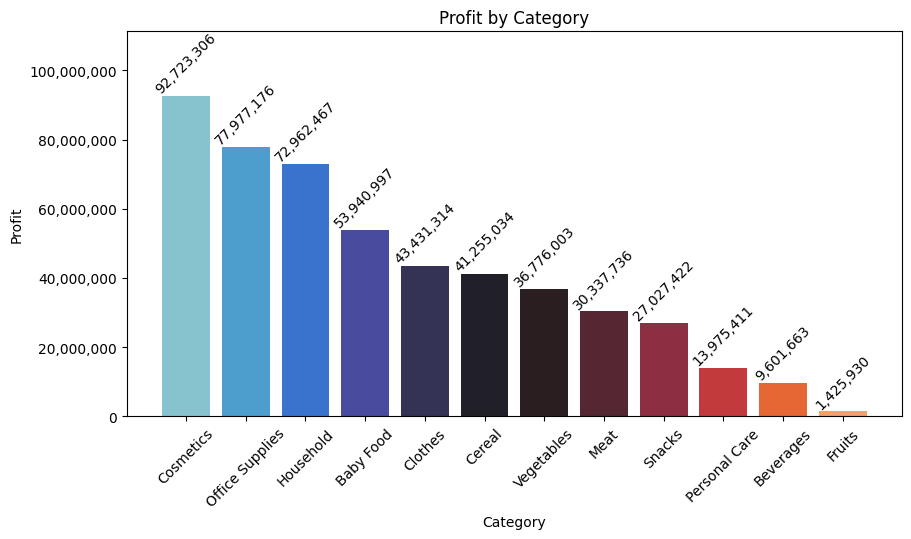

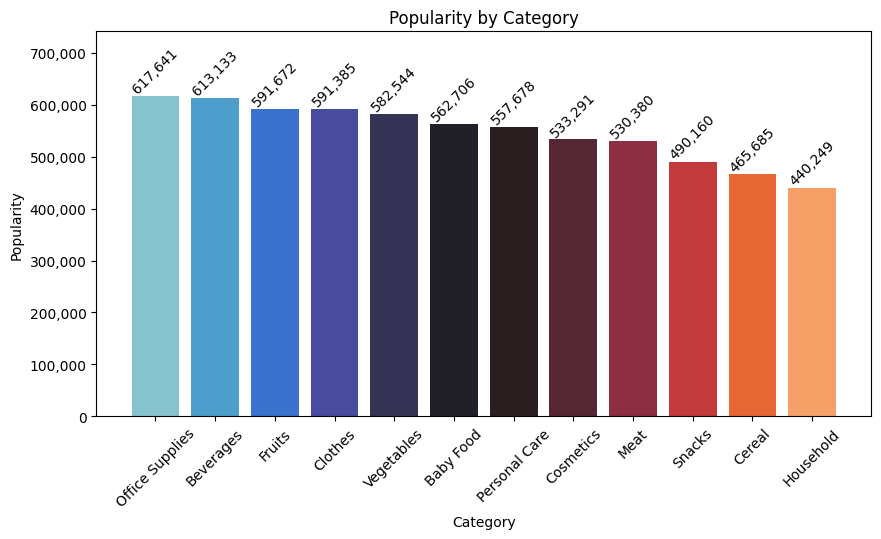

In [ ]:
#Bar Revenue by Category
df["revenue"] = df["units_sold"] * df["unit_price"]
revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

colors = sns.color_palette("icefire", len(revenue_by_category))

plt.figure(figsize=(10, 5))
bars = plt.bar(revenue_by_category.index, revenue_by_category.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}', rotation=45)
plt.ylim(0, revenue_by_category.max() * 1.2)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

#Bar Cost by Category
df["costs"] = df["units_sold"] * df["unit_cost"]
cost_by_category = df.groupby("category")["costs"].sum().sort_values(ascending=False)

colors = sns.color_palette("icefire", len(cost_by_category))

plt.figure(figsize=(10, 5))
bars = plt.bar(cost_by_category.index, cost_by_category.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}', rotation=45)
plt.ylim(0, cost_by_category.max() * 1.2)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Costs by Category")
plt.xlabel("Category")
plt.ylabel("Cost")

#Bar Profit by Category
df["profit"] = ((df["unit_price"] - df["unit_cost"]) * df["units_sold"])

profit_by_category = df.groupby("category")["profit"].sum().sort_values(ascending=False)

colors = sns.color_palette("icefire", len(profit_by_category))

plt.figure(figsize=(10, 5))
bars = plt.bar(profit_by_category.index, profit_by_category.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}', rotation=45)
plt.ylim(0, profit_by_category.max() * 1.2)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

#Bar Popularity by Category

popularity_by_category = df.groupby("category")["units_sold"].sum().sort_values(ascending=False)

colors = sns.color_palette("icefire", len(popularity_by_category))

plt.figure(figsize=(10, 5))
bars = plt.bar(popularity_by_category.index, popularity_by_category.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}', rotation=45)
plt.ylim(0, popularity_by_category.max() * 1.2)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Popularity by Category")
plt.xlabel("Category")
plt.ylabel("Popularity")


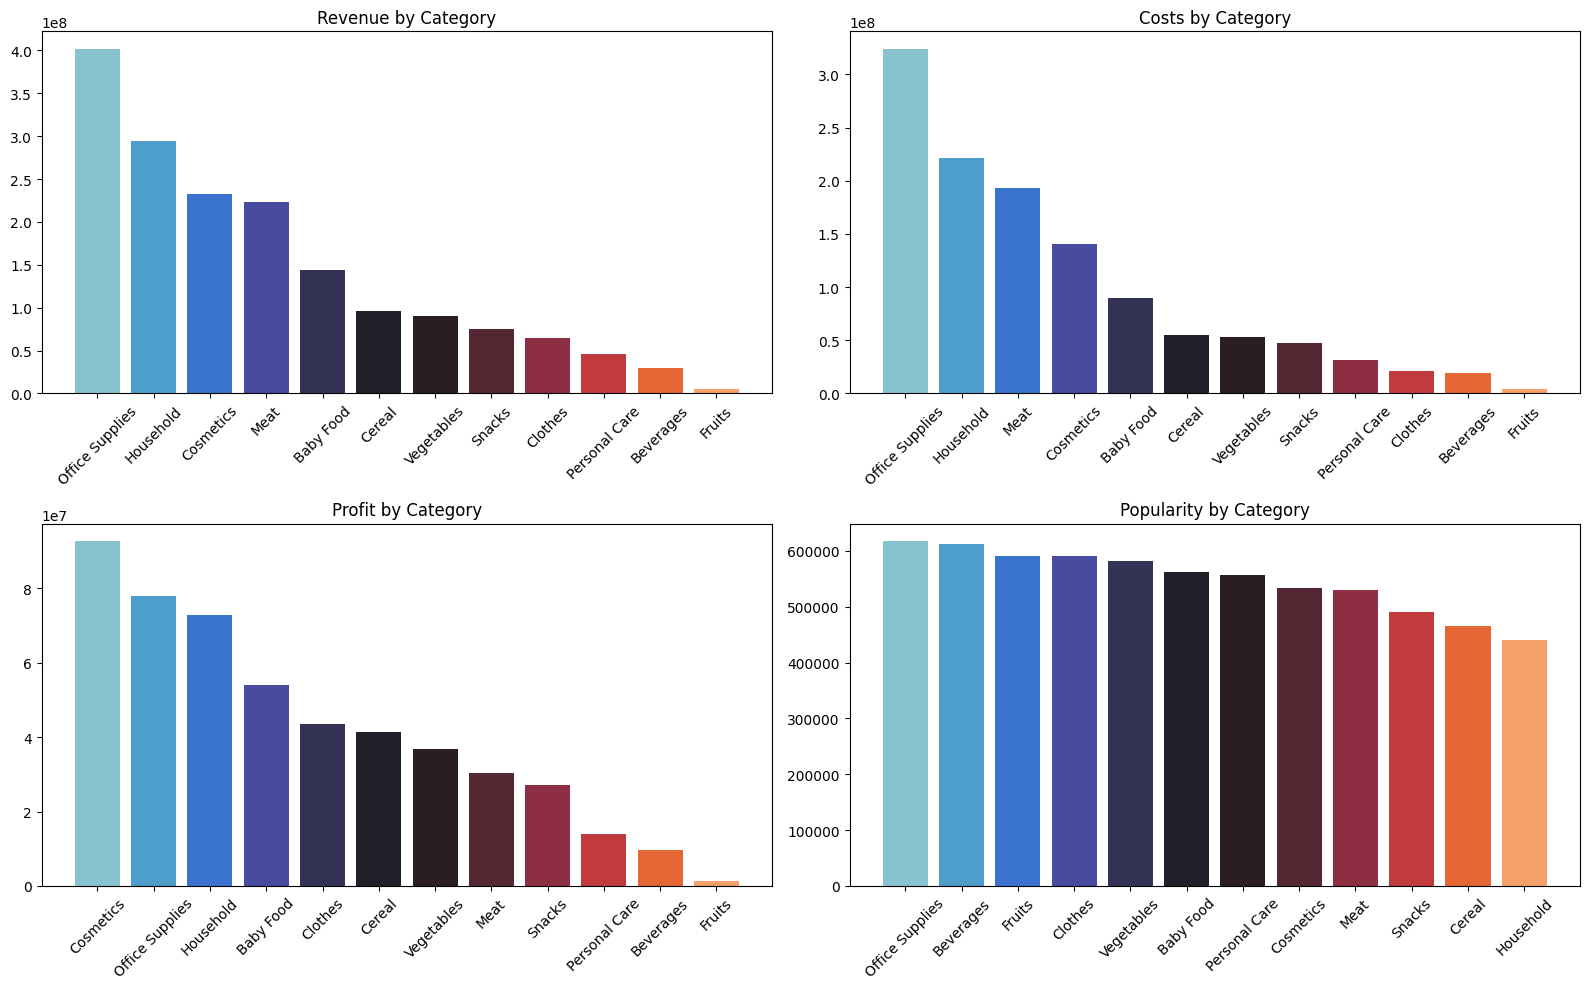

In [ ]:
#Arrays of bars
fig, ax = plt.subplots(2, 2, figsize=(16,10))
ax[0, 0].bar(revenue_by_category.index, revenue_by_category.values, color=colors)
ax[0, 0].set_title("Revenue by Category")
ax[0, 0].tick_params(axis='x', rotation=45)

ax[0, 1].bar(cost_by_category.index, cost_by_category.values, color=colors)
ax[0, 1].set_title("Costs by Category")
ax[0, 1].tick_params(axis='x', rotation=45)

ax[1, 0].bar(profit_by_category.index, profit_by_category.values, color=colors)
ax[1, 0].set_title("Profit by Category")
ax[1, 0].tick_params(axis='x', rotation=45)

ax[1, 1].bar(popularity_by_category.index, popularity_by_category.values, color=colors)
ax[1, 1].set_title("Popularity by Category")
ax[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Найбільш прибутковими для компанії є категорії косметика, канцелярське приладдя та товари для дому ; найбільший дохід приносять ті ж самі категорії.

В той час як найменш прибутковими є фрукти, напої та товари для особистого догляду. При цьому і категорія фрукти і категорія напої входять в топ3 категорій за популярністю. Це може бути обумовлено низбкою вартістю за одиницю товару.

###Sales Analysis by Countries

In [ ]:
#Revenue Map
import plotly.express as px

country_revenue = (
    df.groupby(["alpha_3", "country"])["revenue"].sum().reset_index())

fig = px.choropleth(country_revenue, locations="alpha_3", color="revenue", hover_name="country",
                    color_continuous_scale="Blues", scope="europe", title="Revenue by Country")

fig.show()

Графік демонструє що більший дохід приносять країни переважно Східної Європи.

In [ ]:
#Popularity Map
country_popularity = (df.groupby(["alpha_3", "country"])["units_sold"].sum().reset_index())

fig = px.choropleth(country_popularity, locations="alpha_3", color="units_sold", hover_name="country",
                    color_continuous_scale="reds", scope="europe", title="Popularity by Country")

fig.show()

Згідно з графіком, більша кількість одиниць товару продається також в країнах Східної Європи.

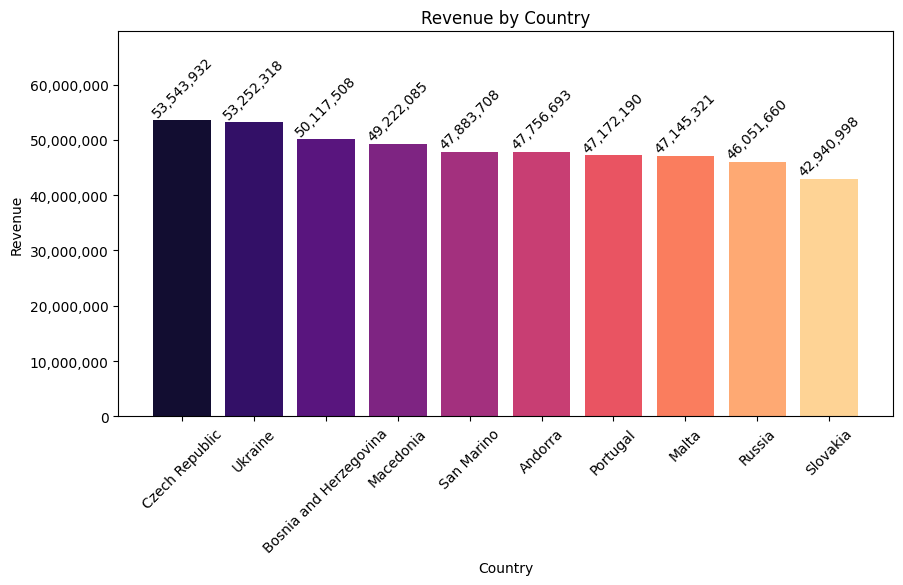

In [ ]:
#Top 10 Countries by Revenue

revenue_by_country = df.groupby("country")["revenue"].sum().sort_values(ascending=False).head(10)
colors = sns.color_palette("magma", len(revenue_by_country))

plt.figure(figsize=(10, 5))
bars = plt.bar(revenue_by_country.index, revenue_by_country.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}', rotation=45)
plt.ylim(0, revenue_by_country.max() * 1.3)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

У топ-10 країн за доходом переважають країни Східної Європи. Найбільший дохід компанії приносять продажі в таких країнах як: Чехія, Україна, Боснія і Герцеговина.

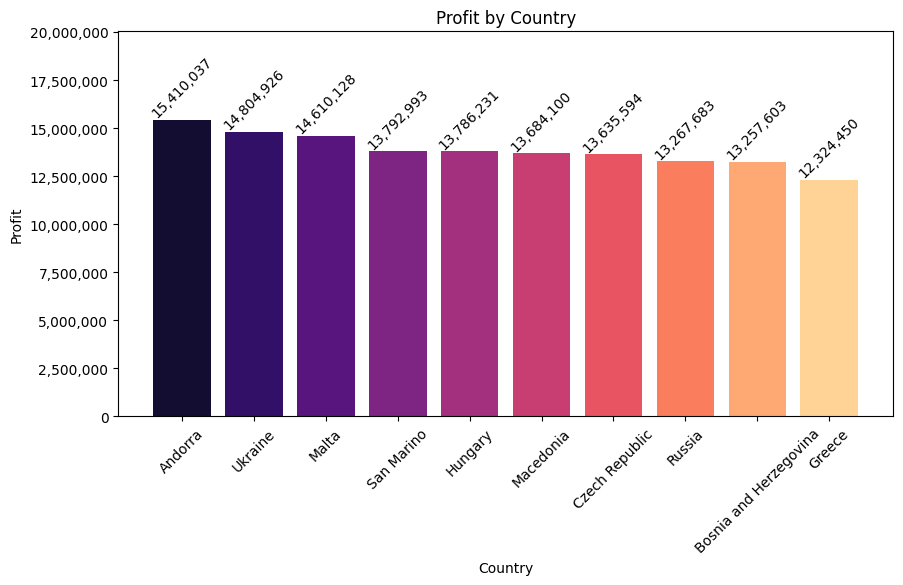

In [ ]:
#Top 10 Countries by Profit

profit_by_country = df.groupby("country")["profit"].sum().sort_values(ascending=False).head(10)
colors = sns.color_palette("magma", len(profit_by_country))

plt.figure(figsize=(10, 5))
bars = plt.bar(profit_by_country.index, profit_by_country.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}', rotation=45)
plt.ylim(0, profit_by_country.max() * 1.3)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Profit by Country")
plt.xlabel("Country")
plt.ylabel("Profit")
plt.show()

Найбільший загальний прибуток компанії приносять продажі в таких країнах як: Андорра, Україна, Мальта.

###Sales Analysis by Sales Channel

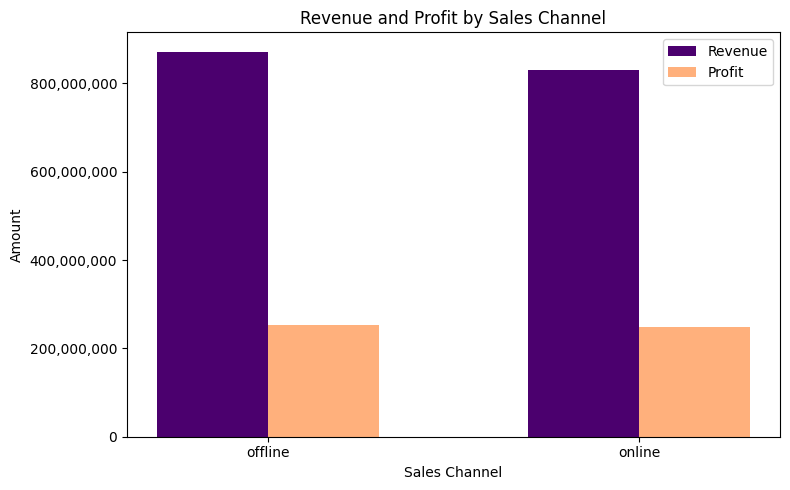

In [ ]:
#Revenue and Profit by Sales Channel
channel_summary = (df.groupby("sales_channel", as_index=False).agg(
          revenue=("revenue", "sum"),
          profit=("profit", "sum")))

metrics = ["revenue", "profit"]
x = np.arange(len(channel_summary))
width = 0.3
colors = ["#4b006e", "#ffb07c"]

plt.figure(figsize=(8, 5))

for i, metric in enumerate(metrics):
    plt.bar(x + (i - 0.5) * width, channel_summary[metric], width, label=metric.capitalize(), color=colors[i])

plt.xticks(x, channel_summary["sales_channel"])

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Revenue and Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()

plt.show()

Діаграма демонструє приблизно однаковий розподіл прибутку в залежності від каналу продажу і незначне переважання доходу від продажів через offline канал.

###Sales Analysis by Shipping Days

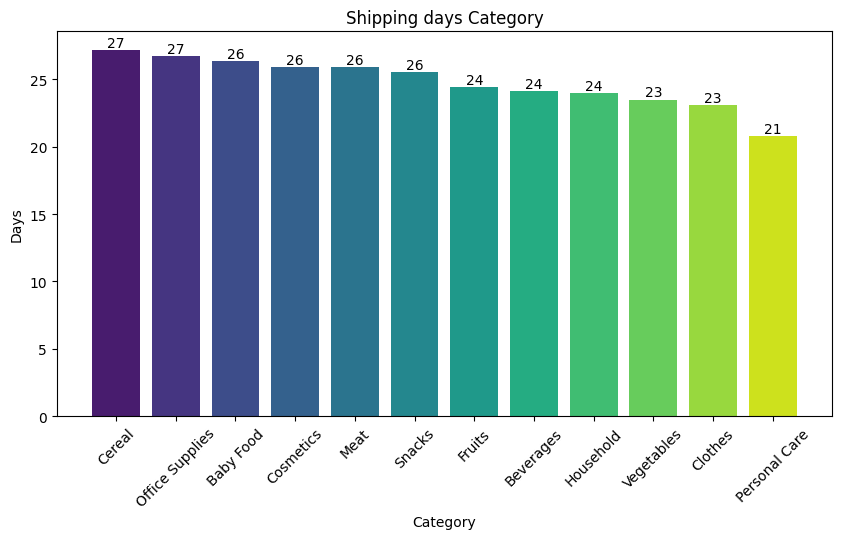

In [ ]:
# Shipping days be Category

df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

shipping_days_by_category = df.groupby("category")["shipping_days"].mean().sort_values(ascending=False)

colors = sns.color_palette("viridis", len(shipping_days_by_category))

plt.figure(figsize=(10, 5))
bars = plt.bar(shipping_days_by_category.index, shipping_days_by_category.values, color=colors)
plt.bar_label(bars, fmt='{:,.0f}')

plt.xticks(rotation=45)

plt.title("Shipping days Category")
plt.xlabel("Category")
plt.ylabel("Days")
plt.show()

Згідно з графіком, найдовший час на відвантаження займають категорії Злакові культури та Канцелярське приладдя (27 днів), а найменше часу - Засоби для особистого догляду та Одяг.

In [ ]:
#Shipping Days Map
country_shipping_days = (df.groupby(["alpha_3","country"])["shipping_days"].mean().reset_index())

fig = px.choropleth(country_shipping_days, locations="alpha_3", color="shipping_days", hover_name="country",
                    color_continuous_scale="viridis", scope="europe", title="Shipping Days by Country")

fig.show()

Згідно з картою, чіткої залежності між країною та строками доставки товару не простежується. Водночас можна помітити, що дещо коротші строки доставки характерні для країн із виходом до моря порівняно з країнами, розташованими всередині континенту.

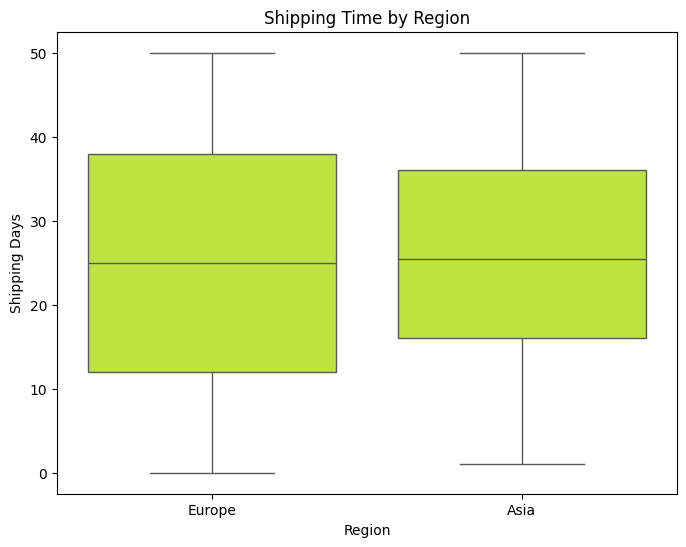

In [ ]:
#Shipping time by Region Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="region", y="shipping_days", color="#c9ff27")

plt.title("Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Shipping Days")

plt.show()

Медіанний час доставки в обох регіонах складає приблизно 25 днів, при цьому в Європі 25% доставок відбуваються за 12 днів, або менше, і 75% за 38 днів, або менше. В Азії 25% за 16 днів або швидше, і 75% за 36 днів або швидше. Є викиди як в один бік, так і в інший, максимальні дні доставки досягають 50, мінімальні 0-1.

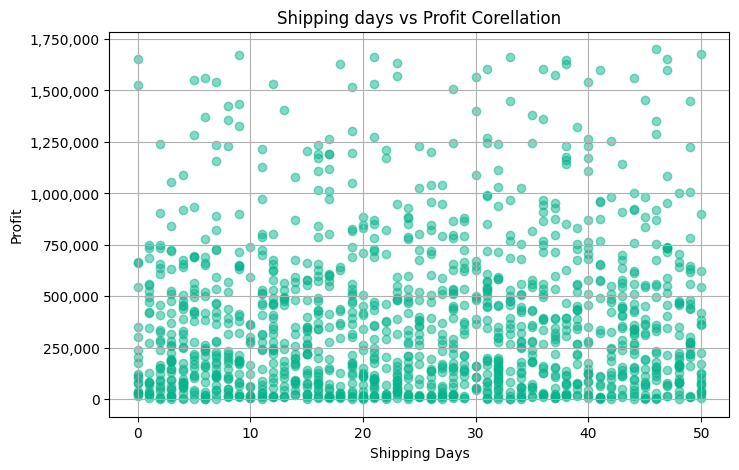

In [ ]:
#Shipping days vs Profit Scatter
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit"] = ((df["unit_price"] - df["unit_cost"]) * df["units_sold"])

plt.figure(figsize=(8, 5))

plt.scatter(df["shipping_days"], df["profit"], alpha=0.5, color="#06b48b")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Shipping Days")
plt.ylabel("Profit")
plt.title("Shipping days vs Profit Corellation")
plt.grid(True)
plt.show()

Візуальний аналіз scatter plot не показує чіткої залежності між часом відвантаження та прибутком.

###Sales Dynamic Analysis

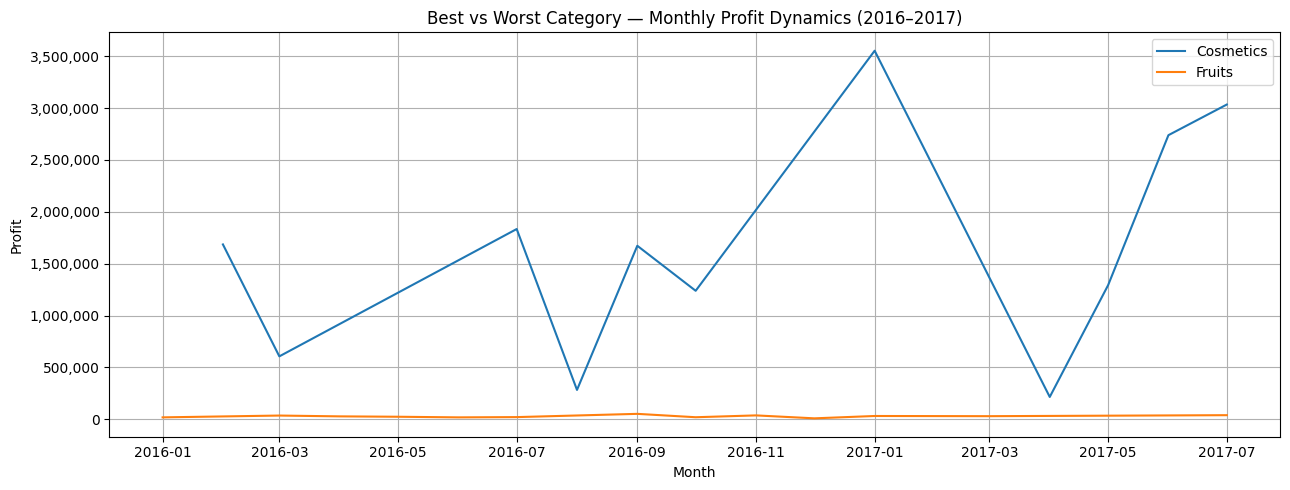

In [ ]:
#Comparing best and worst category profit last 2 years
df_recent = df[df["order_date"].dt.year >= 2016].copy() #last 2 years
df_recent["month"] = df_recent["order_date"].dt.to_period("M") #column with year-month period

sales_recent = (df_recent.groupby(["month", "category"], as_index=False).agg(profit=("profit", "sum"))) #aggregation monthly profit by category
sales_recent["month"] = sales_recent["month"].dt.to_timestamp() #back to timestamp for plotting

category_profit = (df_recent.groupby("category")["profit"].sum().sort_values(ascending=False)) #profit by category and sort in descending order

best_category = category_profit.index[0] #best category
worst_category = category_profit.index[-1] #worst category

plt.figure(figsize=(13, 5))

for cat in [best_category, worst_category]:
    data_cat = sales_recent[sales_recent["category"] == cat] #filter for the current category using a boolean mask
    plt.plot(data_cat["month"], data_cat["profit"], label=cat) #making a plot

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Best vs Worst Category — Monthly Profit Dynamics (2016–2017)")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Динаміка прибутку в категорії «Косметика» за останні два роки характеризується значною волатильністю. Спостерігаються виражені пікові значення у січні та липні 2017 року, між якими зафіксовано суттєве зниження показника.

Натомість категорія «Фрукти» демонструє відносно стабільну динаміку без різких коливань, що може бути пов’язано з нижчою ціною за одиницю товару та більш рівномірним попитом.

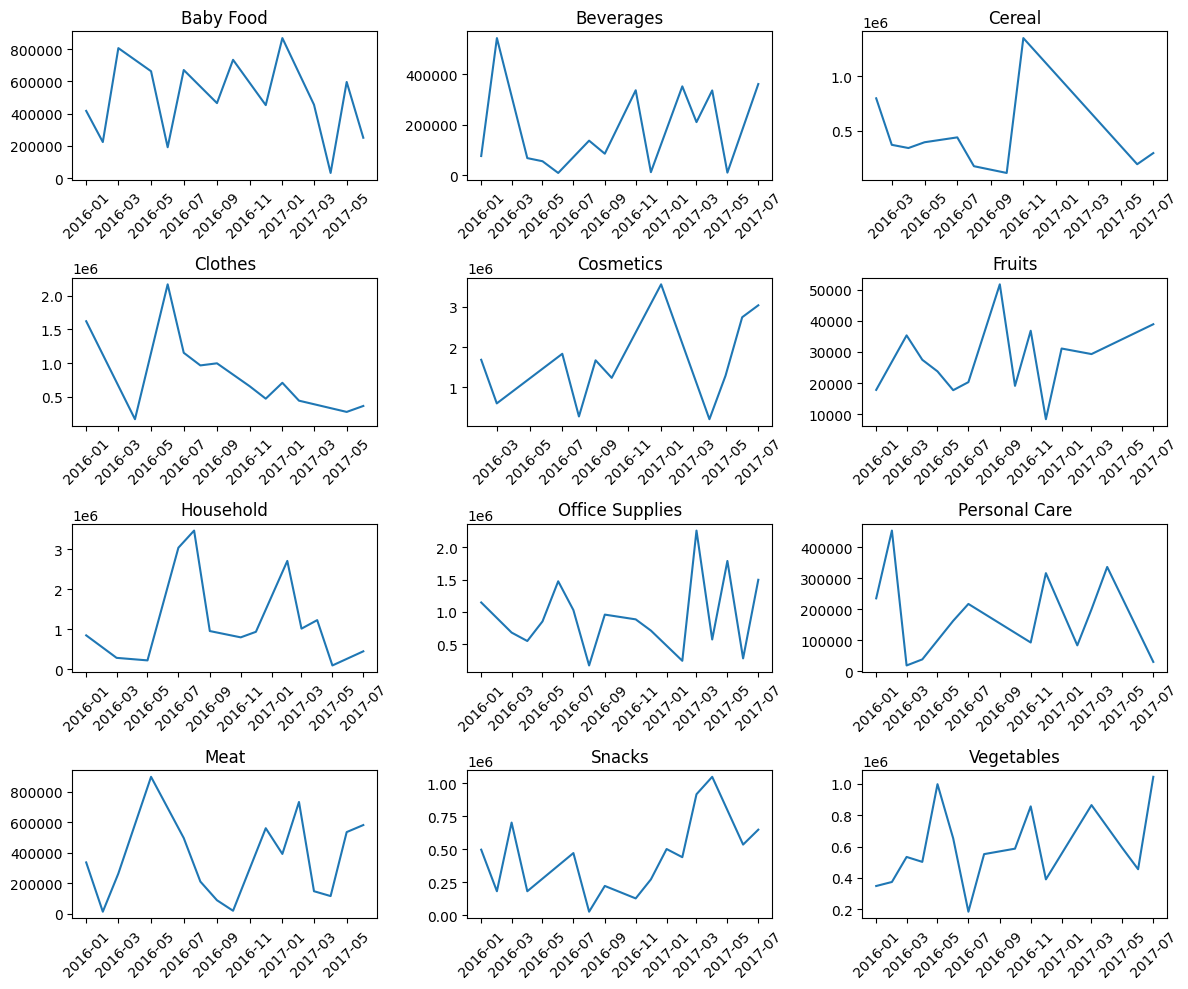

In [ ]:
#Profit by all categories

df_recent = df[df["order_date"].dt.year >= 2016].copy()
df_recent["month"] = df_recent["order_date"].dt.to_period("M")

sales_recent = (df_recent.groupby(["month", "category"], as_index=False).agg(profit=("profit", "sum")))
sales_recent["month"] = sales_recent["month"].dt.to_timestamp()

# Create a figure with 4 rows and 3 columns of subplots
fig, ax = plt.subplots(4, 3, figsize=(12, 10))

# Baby Food
data = sales_recent[sales_recent["category"] == "Baby Food"]
ax[0,0].plot(data["month"], data["profit"])
ax[0,0].set_title("Baby Food")
ax[0,0].tick_params(axis='x', rotation=45)

# Beverages
data = sales_recent[sales_recent["category"] == "Beverages"]
ax[0,1].plot(data["month"], data["profit"])
ax[0,1].set_title("Beverages")
ax[0,1].tick_params(axis='x', rotation=45)

# Cereal
data = sales_recent[sales_recent["category"] == "Cereal"]
ax[0,2].plot(data["month"], data["profit"])
ax[0,2].set_title("Cereal")
ax[0,2].tick_params(axis='x', rotation=45)

# Clothes
data = sales_recent[sales_recent["category"] == "Clothes"]
ax[1,0].plot(data["month"], data["profit"])
ax[1,0].set_title("Clothes")
ax[1,0].tick_params(axis='x', rotation=45)

# Cosmetics
data = sales_recent[sales_recent["category"] == "Cosmetics"]
ax[1,1].plot(data["month"], data["profit"])
ax[1,1].set_title("Cosmetics")
ax[1,1].tick_params(axis='x', rotation=45)

# Fruits
data = sales_recent[sales_recent["category"] == "Fruits"]
ax[1,2].plot(data["month"], data["profit"])
ax[1,2].set_title("Fruits")
ax[1,2].tick_params(axis='x', rotation=45)

# Household
data = sales_recent[sales_recent["category"] == "Household"]
ax[2,0].plot(data["month"], data["profit"])
ax[2,0].set_title("Household")
ax[2,0].tick_params(axis='x', rotation=45)

# Office Supplies
data = sales_recent[sales_recent["category"] == "Office Supplies"]
ax[2,1].plot(data["month"], data["profit"])
ax[2,1].set_title("Office Supplies")
ax[2,1].tick_params(axis='x', rotation=45)

# Personal Care
data = sales_recent[sales_recent["category"] == "Personal Care"]
ax[2,2].plot(data["month"], data["profit"])
ax[2,2].set_title("Personal Care")
ax[2,2].tick_params(axis='x', rotation=45)

# Meat
data = sales_recent[sales_recent["category"] == "Meat"]
ax[3,0].plot(data["month"], data["profit"])
ax[3,0].set_title("Meat")
ax[3,0].tick_params(axis='x', rotation=45)

# Snacks
data = sales_recent[sales_recent["category"] == "Snacks"]
ax[3,1].plot(data["month"], data["profit"])
ax[3,1].set_title("Snacks")
ax[3,1].tick_params(axis='x', rotation=45)

# Vegetables
data = sales_recent[sales_recent["category"] == "Vegetables"]
ax[3,2].plot(data["month"], data["profit"])
ax[3,2].set_title("Vegetables")
ax[3,2].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()


Усі графіки демонструють високу волатильність прибутку протягом аналізованого періоду.

Для категорій Злакові культури, Фрукти та Овочі різкі зростання та спадання можуть бути пов’язані із сезонністю врожаю та коливанням пропозиції.

Категорії Косметика та Товари для дому демонструють суттєве зростання у передноворічний період, що, ймовірно, зумовлено сезонним попитом та святковою активністю споживачів.

Водночас категорія Одяг приносить найвищі прибутки у літній період, тоді як категорія М’ясо демонструє пікові значення навесні.

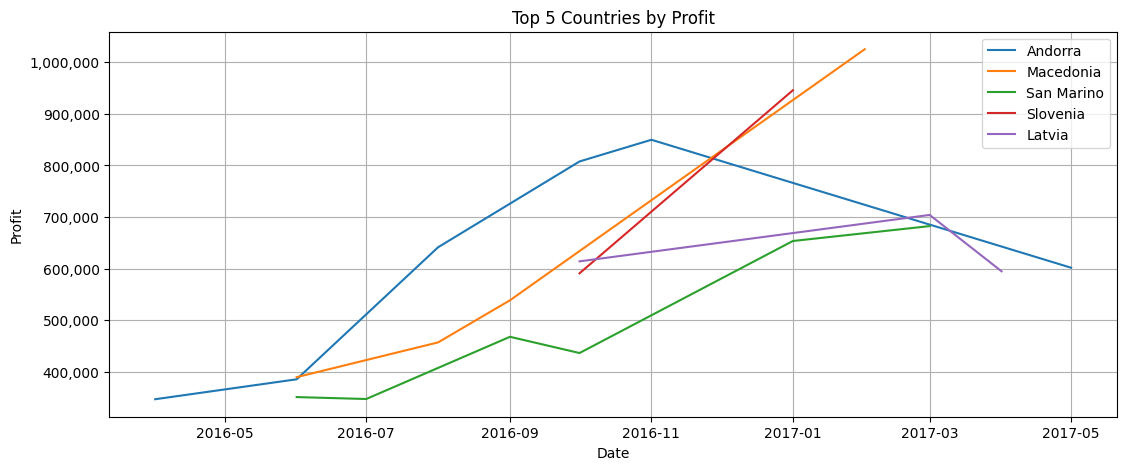

In [ ]:
# Top 5 countries by profit dynamic (last two years)
df_recent = df[df["order_date"].dt.year >= 2016].copy()  #last 2 years
df_recent["month"] = df_recent["order_date"].dt.to_period("M")  #column with year-month period

top5_countries = (df_recent.groupby("country")["profit"].sum().sort_values(ascending=False)
    .head(5).index)  # top 5 countries by profit

sales_recent_country = (df_recent[df_recent["country"].isin(top5_countries)]
    .groupby(["month", "country"], as_index=False).agg(profit=("profit", "sum")))  #final aggregation with 3 columns: country, month, profit

sales_recent_country["month"] = sales_recent_country["month"].dt.to_timestamp()  #back to timestamp

plt.figure(figsize=(13, 5))

for country in top5_countries:
    top_profit = sales_recent_country[sales_recent_country["country"] == country]  #filter for the current country using a boolean mask

    smooth = top_profit["profit"].rolling(4, center=True).mean() #average over 4 months to smooth the plot

    plt.plot(top_profit["month"], smooth, label=country) #building a plot

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Date")
plt.ylabel("Profit")
plt.title("Top 5 Countries by Profit")
plt.legend()
plt.grid(True)
plt.show()


Динаміка прибутку в топ-5 країнах є нерівномірною та характеризується певними коливаннями протягом двох останніх років. Найбільш стабільне зростання демонструє Македонія та Сан-Марино, тоді як інші країни мають періоди різкого зростання та подальших спадів.

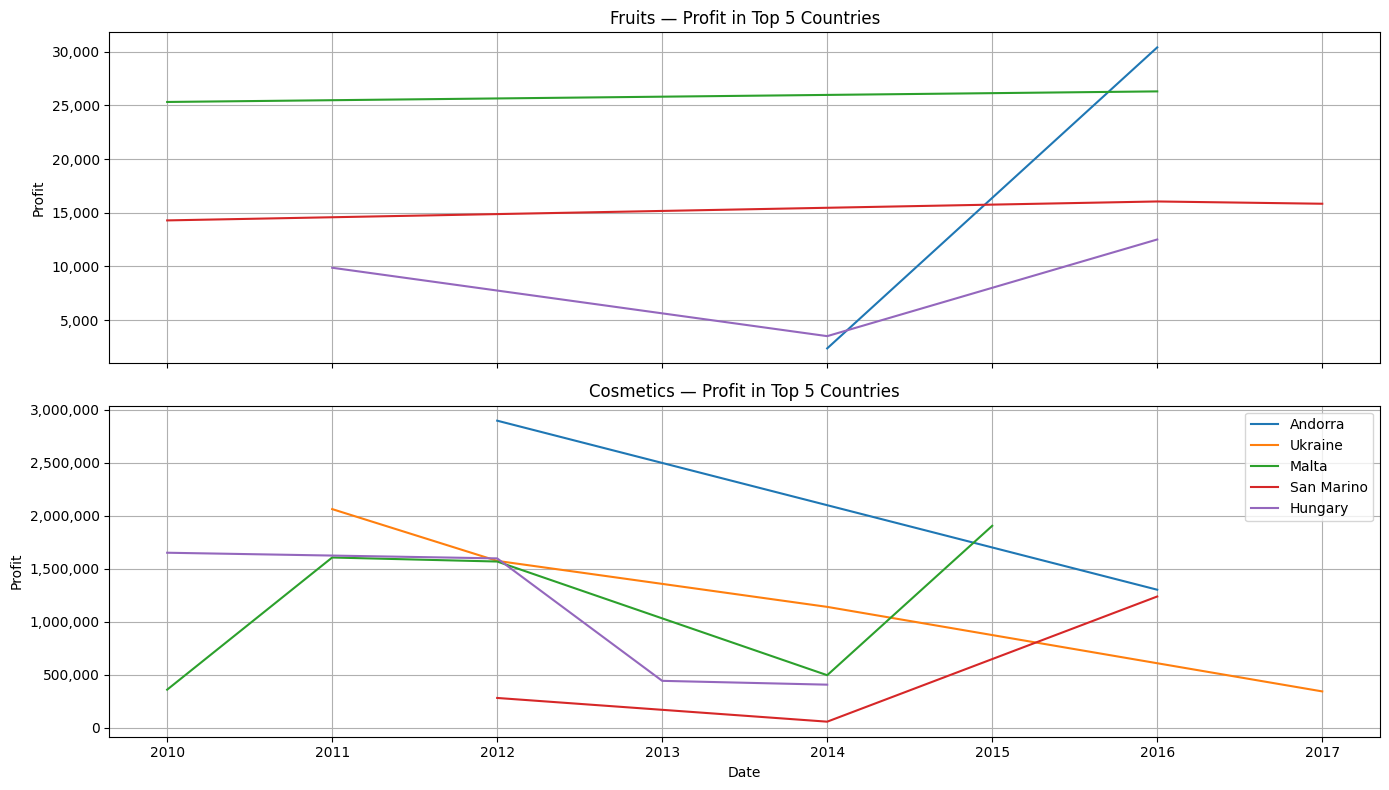

In [ ]:
# Comparing dynamic between best and worst categoties in top-5 countries (all period)
df_all = df.copy()
df_all["year"] = df_all["order_date"].dt.year #column with year-month period

top5_countries = (df_all.groupby("country")["profit"].sum().sort_values(ascending=False).head(5).index) #top 5 countries by profit

sales_fruits = (
    df_all[df_all["country"].isin(top5_countries) &
        (df_all["category"] == "Fruits")]
    .groupby(["year", "country"], as_index=False).agg(profit=("profit", "sum"))) #final aggregation for country, fruits, month, profit


sales_cosmetics = (
    df_all[df_all["country"].isin(top5_countries) &
        (df_all["category"] == "Cosmetics")]
    .groupby(["year", "country"], as_index=False).agg(profit=("profit", "sum"))) #final aggregation for country, cosmetics, month, profit


fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# fruits plot
for country in top5_countries:
    data_country = sales_fruits[sales_fruits["country"] == country]
    axes[0].plot(data_country["year"], data_country["profit"], label=country)

axes[0].set_title("Fruits — Profit in Top 5 Countries")
axes[0].set_ylabel("Profit")
axes[0].grid(True)
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# cosmetics plot
for country in top5_countries:
    data_country = sales_cosmetics[sales_cosmetics["country"] == country]
    axes[1].plot(data_country["year"], data_country["profit"], label=country)

axes[1].set_title("Cosmetics — Profit in Top 5 Countries")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Profit")
axes[1].grid(True)
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

axes[1].legend()

plt.tight_layout()
plt.show()


Прибуток від продажу найменш прибуткової категорії Фрукти у топових країнах характеризується відносною стабільністю та помірною тенденцією до зростання в останні роки. Водночас категорія Косметика демонструє загальну тенденцію до зниження прибутковості в більшості країн, за винятком Сан-Марино та Мальти, де спостерігається зростання.

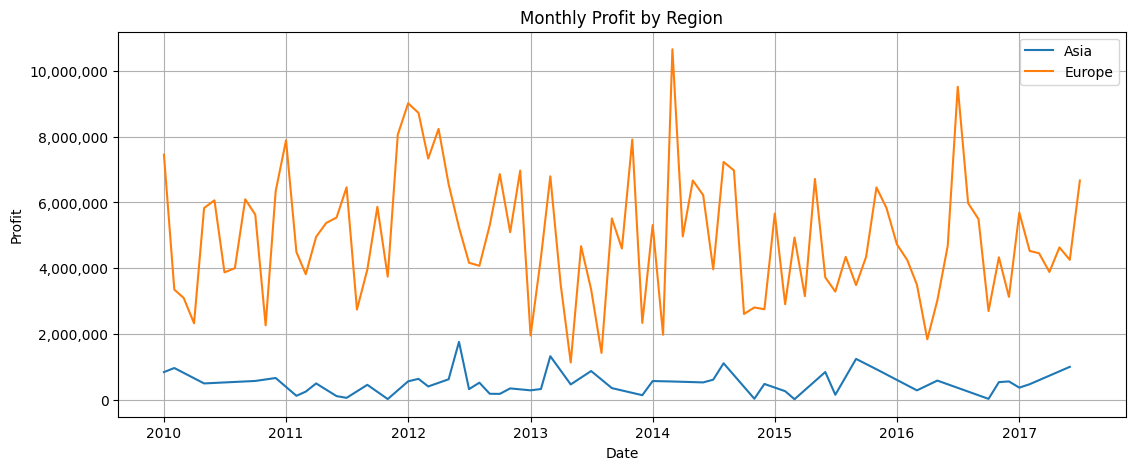

In [ ]:
# Profit dynamic by Region
df_all = df.copy()
df_all["month"] = df_all["order_date"].dt.to_period("M") #column with year-month period

region_profit_month = (df_all.groupby(["month", "region"], as_index=False).agg(profit=("profit", "sum"))) #aggregation monthly profit by region

region_profit_month["month"] = region_profit_month["month"].dt.to_timestamp() #back to timestamp


plt.figure(figsize=(13, 5))
for region in region_profit_month["region"].unique():
    region_profit = region_profit_month[region_profit_month["region"] == region] #filter for the current region using a boolean mask
    plt.plot(region_profit["month"], region_profit["profit"], label=region) #building a plot

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Date")
plt.ylabel("Profit")
plt.title("Monthly Profit by Region")
plt.legend()
plt.grid(True)
plt.show()

У країнах Європи обсяг прибутку характеризується високою волатильністю, тоді як в Азії коливання є значно менш вираженими. Така різниця може бути пов’язана з відмінностями в загальному обʼємі продажів між європейськими та азійськими країнами.

###Sales by Weekday Analysis

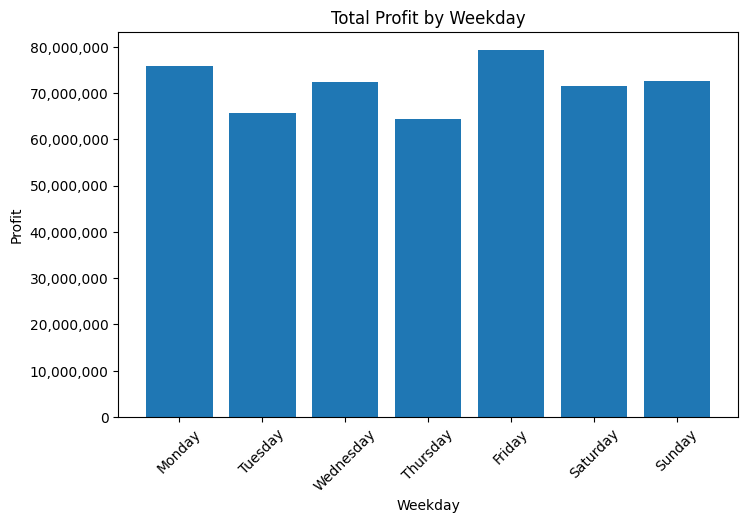

In [ ]:
# Profit by weekday
df_all = df.copy()

df_all["weekday"] = df_all["order_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

profit_by_weekday = (df_all.groupby("weekday", as_index=False).agg(total_profit=("profit", "sum")))

profit_by_weekday["weekday"] = pd.Categorical(profit_by_weekday["weekday"], categories=weekday_order, ordered=True)

profit_by_weekday = profit_by_weekday.sort_values("weekday")

plt.figure(figsize=(8,5))

plt.bar(profit_by_weekday["weekday"], profit_by_weekday["total_profit"])

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Total Profit by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()


Найбільший прибуток компанії приносять продажі в такі дні як Пʼятниця, Субота, Неділя і Понеділок, з подальшим спадом протягом робочого тижня.

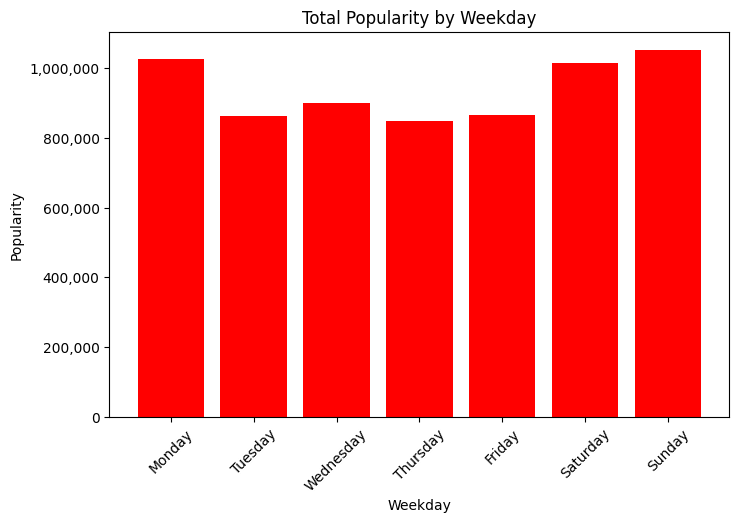

In [ ]:
# Popularity by weekday
df_all = df.copy()

df_all["weekday"] = df_all["order_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
popularity_by_weekday = (df_all.groupby("weekday", as_index=False).agg(total_popularity=("units_sold", "sum")))

popularity_by_weekday["weekday"] = pd.Categorical(popularity_by_weekday["weekday"], categories=weekday_order, ordered=True)

popularity_by_weekday = popularity_by_weekday.sort_values("weekday")

plt.figure(figsize=(8,5))

plt.bar(popularity_by_weekday["weekday"], popularity_by_weekday["total_popularity"], color="red")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Total Popularity by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Popularity")
plt.xticks(rotation=45)
plt.show()

Найбільш успішними по кількості проданих одиниць товару має компанія в такі дні тижня: Понеділок, Субота, Неділя.